# Relations

A **relation** describes how the elements of one set are connected to the elements of another. Formally, a **binary relation** from a set $A$ to a set $B$ is a subset $R \subseteq A \times B$ — that is, a set of ordered pairs $(a, b)$. We write $a\,R\,b$ (read "$a$ is related to $b$") when $(a, b) \in R$.

When $A = B$, we call $R$ a **relation on $A$**. Relations are everywhere in computing: "is less than," "divides," "is connected to," "has the same remainder as," and the rows of a database table are all relations.

## Relations as Sets of Pairs

The most direct representation of a relation is simply the set of pairs that belong to it. For example, on $A = \{1, 2, 3, 4\}$ the relation "$a$ divides $b$" is the set of all pairs $(a, b)$ for which $b$ is a multiple of $a$.

In [1]:
A = [1, 2, 3, 4]

# Build the "divides" relation on A as a set of ordered pairs.
divides = {(a, b) for a in A for b in A if b % a == 0}

print("divides =", sorted(divides))
print("Is (2, 4) in the relation? (does 2 divide 4)", (2, 4) in divides)
print("Is (3, 4) in the relation? (does 3 divide 4)", (3, 4) in divides)

divides = [(1, 1), (1, 2), (1, 3), (1, 4), (2, 2), (2, 4), (3, 3), (4, 4)]
Is (2, 4) in the relation? (does 2 divide 4) True
Is (3, 4) in the relation? (does 3 divide 4) False


## Representing a Relation as a Matrix

A relation on a finite set $A = \{a_1, \dots, a_n\}$ can be stored as an $n \times n$ **zero-one matrix** $M$, where

$$M_{ij} = \begin{cases} 1 & \text{if } (a_i, a_j) \in R \\ 0 & \text{otherwise.}\end{cases}$$

This connects relations back to the matrices from notebook 05, and it is how a computer usually stores a relation (or a graph — see notebook 12).

In [2]:
import numpy as np

def relation_matrix(R, A):
    n = len(A)
    M = np.zeros((n, n), dtype=int)
    index = {a: i for i, a in enumerate(A)}
    for (a, b) in R:
        M[index[a], index[b]] = 1
    return M

M = relation_matrix(divides, A)
print("Zero-one matrix of 'divides' on", A, "\n")
print(M)
print("\nRow i, column j is 1 exactly when A[i] divides A[j].")

Zero-one matrix of 'divides' on [1, 2, 3, 4] 

[[1 1 1 1]
 [0 1 0 1]
 [0 0 1 0]
 [0 0 0 1]]

Row i, column j is 1 exactly when A[i] divides A[j].


## Representing a Relation as a Directed Graph

A relation on $A$ can also be drawn as a **directed graph** (digraph): one node per element, and an arrow from $a$ to $b$ whenever $(a, b) \in R$. A pair $(a, a)$ shows up as a **self-loop**. This visual view makes the *properties* of a relation (below) easy to recognize.

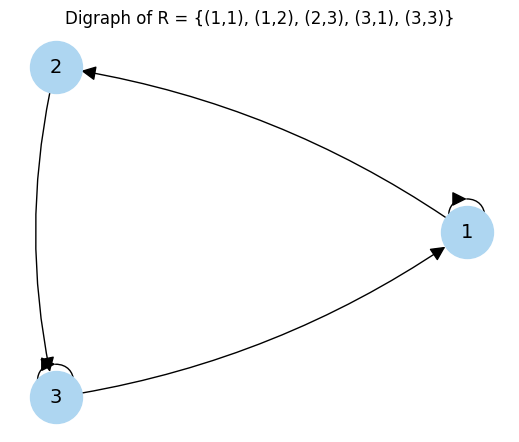

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

R = {(1, 1), (1, 2), (2, 3), (3, 1), (3, 3)}

G = nx.DiGraph()
G.add_nodes_from([1, 2, 3])
G.add_edges_from(R)

pos = nx.circular_layout(G)
plt.figure(figsize=(5, 4))
nx.draw(G, pos, with_labels=True, node_color="#aed6f1", node_size=1400,
        font_size=14, arrowsize=22, connectionstyle="arc3,rad=0.12")
plt.title("Digraph of R = {(1,1), (1,2), (2,3), (3,1), (3,3)}")
plt.show()

## Properties of Relations

Four properties of a relation $R$ on a set $A$ come up constantly. For all $a, b, c \in A$:

| Property | Definition |
|---|---|
| **Reflexive** | $(a, a) \in R$ for every $a \in A$ |
| **Symmetric** | if $(a, b) \in R$ then $(b, a) \in R$ |
| **Antisymmetric** | if $(a, b) \in R$ and $(b, a) \in R$ then $a = b$ |
| **Transitive** | if $(a, b) \in R$ and $(b, c) \in R$ then $(a, c) \in R$ |

We can translate each definition directly into a small Python test.

In [4]:
def is_reflexive(R, A):
    return all((a, a) in R for a in A)

def is_symmetric(R):
    return all((b, a) in R for (a, b) in R)

def is_antisymmetric(R):
    # No two DISTINCT elements may be related in both directions.
    return all(a == b for (a, b) in R if (b, a) in R)

def is_transitive(R):
    return all((a, c) in R for (a, b1) in R for (b2, c) in R if b1 == b2)

def describe(name, R, A):
    print(f"{name}:")
    print(f"   reflexive={is_reflexive(R, A)}  symmetric={is_symmetric(R)}  "
          f"antisymmetric={is_antisymmetric(R)}  transitive={is_transitive(R)}")

## Classifying Some Relations

Let us test four relations on $A = \{1, 2, 3, 4\}$:

- $\le$ (less than or equal to),
- "divides",
- $\ne$ (not equal),
- congruence modulo $2$ (same parity).

In [5]:
A = [1, 2, 3, 4]

leq        = {(a, b) for a in A for b in A if a <= b}
divides    = {(a, b) for a in A for b in A if b % a == 0}
not_equal  = {(a, b) for a in A for b in A if a != b}
same_parity = {(a, b) for a in A for b in A if a % 2 == b % 2}

describe("<=          ", leq, A)
describe("divides     ", divides, A)
describe("not-equal   ", not_equal, A)
describe("same parity ", same_parity, A)

<=          :
   reflexive=True  symmetric=False  antisymmetric=True  transitive=True
divides     :
   reflexive=True  symmetric=False  antisymmetric=True  transitive=True
not-equal   :
   reflexive=False  symmetric=True  antisymmetric=False  transitive=False
same parity :
   reflexive=True  symmetric=True  antisymmetric=False  transitive=True


Notice the patterns:

- $\le$ and **divides** are each reflexive, antisymmetric, and transitive — these are **partial orders**.
- **same parity** is reflexive, symmetric, and transitive — this is an **equivalence relation**.
- $\ne$ is symmetric but neither reflexive nor transitive (e.g. $1 \ne 2$ and $2 \ne 1$, but $1 = 1$, so transitivity fails).

## Equivalence Relations and Equivalence Classes

A relation that is **reflexive, symmetric, and transitive** is an **equivalence relation**. An equivalence relation splits its set into disjoint **equivalence classes** — groups of mutually related elements — and these classes form a **partition** of the set (every element lands in exactly one class).

A classic example is **congruence modulo $m$**: $a \equiv b \pmod{m}$ when $a$ and $b$ leave the same remainder on division by $m$. Below we compute the classes of congruence modulo $3$ on $\{0, 1, \dots, 8\}$.

In [6]:
def equivalence_classes(A, related):
    classes = []
    for a in A:
        for cls in classes:
            if related(a, cls[0]):
                cls.append(a)
                break
        else:
            classes.append([a])
    return classes

A = list(range(9))
classes = equivalence_classes(A, lambda a, b: a % 3 == b % 3)

print("Equivalence classes of congruence mod 3 on", A, ":")
for cls in classes:
    print(f"   remainder {cls[0] % 3}: {cls}")
print("\nThe classes are disjoint and cover all of A, so they form a partition.")

Equivalence classes of congruence mod 3 on [0, 1, 2, 3, 4, 5, 6, 7, 8] :
   remainder 0: [0, 3, 6]
   remainder 1: [1, 4, 7]
   remainder 2: [2, 5, 8]

The classes are disjoint and cover all of A, so they form a partition.


## Partial Orders and Hasse Diagrams

A relation that is **reflexive, antisymmetric, and transitive** is a **partial order**. A set together with a partial order is a **poset** (partially ordered set).

We can draw a poset compactly with a **Hasse diagram**: place smaller elements lower, and draw an edge from $a$ up to $b$ only when $b$ *covers* $a$ — meaning $a < b$ with nothing strictly in between. Reflexive loops and edges implied by transitivity are omitted. Below is the Hasse diagram of the **divisibility** order on the divisors of $12$.

cover relation: [(1, 2), (1, 3), (2, 4), (2, 6), (3, 6), (4, 12), (6, 12)]


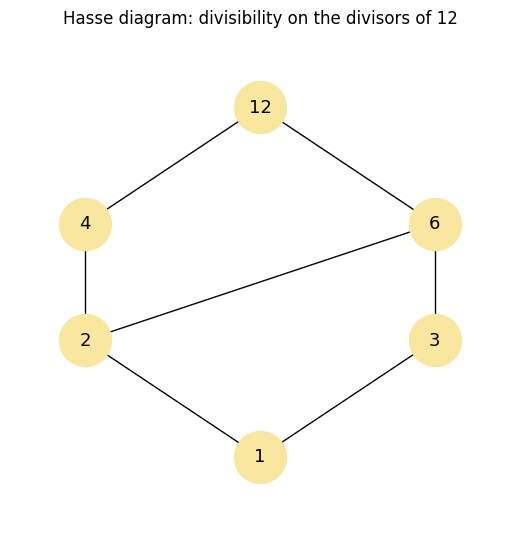

In [7]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

elements = [1, 2, 3, 4, 6, 12]
leq = lambda a, b: b % a == 0          # a <= b means a divides b

# Cover relation: a -> b when a divides b, a != b, and nothing lies strictly between.
covers = []
for a in elements:
    for b in elements:
        if a != b and leq(a, b):
            if not any(c != a and c != b and leq(a, c) and leq(c, b) for c in elements):
                covers.append((a, b))

# Vertical position = number of prime factors (with multiplicity); horizontal = spread.
def num_prime_factors(n):
    count, d = 0, 2
    while d * d <= n:
        while n % d == 0:
            count += 1
            n //= d
        d += 1
    return count + (1 if n > 1 else 0)

rows = defaultdict(list)
for x in elements:
    rows[num_prime_factors(x)].append(x)
pos = {}
for level, nodes in rows.items():
    for i, x in enumerate(sorted(nodes)):
        pos[x] = (i - (len(nodes) - 1) / 2, level)

print("cover relation:", covers)
G = nx.DiGraph()
G.add_nodes_from(elements)
G.add_edges_from(covers)
plt.figure(figsize=(5, 5))
nx.draw(G, pos, with_labels=True, node_color="#f9e79f", node_size=1400,
        font_size=13, arrows=False)
plt.title("Hasse diagram: divisibility on the divisors of 12")
plt.margins(0.15)
plt.show()

## Composition of Relations

If $R$ relates $A$ to $B$ and $S$ relates $B$ to $C$, their **composition** $S \circ R$ relates $A$ to $C$:

$$S \circ R = \{(a, c) : \text{there is some } b \text{ with } (a, b) \in R \text{ and } (b, c) \in S\}.$$

Composition is how you chain relations — for instance, "is a parent of" composed with itself gives "is a grandparent of".

In [8]:
def compose(R, S):
    """Return S after R: pairs (a, c) with (a, b) in R and (b, c) in S."""
    return {(a, c) for (a, b) in R for (b2, c) in S if b == b2}

parent = {("Ann", "Bob"), ("Bob", "Cara"), ("Cara", "Dan")}
grandparent = compose(parent, parent)
greatgrandparent = compose(parent, grandparent)

print("parent          :", sorted(parent))
print("grandparent     :", sorted(grandparent))
print("great-grandparent:", sorted(greatgrandparent))

parent          : [('Ann', 'Bob'), ('Bob', 'Cara'), ('Cara', 'Dan')]
grandparent     : [('Ann', 'Cara'), ('Bob', 'Dan')]
great-grandparent: [('Ann', 'Dan')]


## Worked Examples

A few examples solved with Python. (The exercises in the next section are for you to solve — their solutions live in the matching notebook in `solutions/`.)

### Example 1: How Many Relations Are There?

A relation on a set of size $n$ is any subset of the $n^2$ possible pairs, so there are $2^{n^2}$ relations. Compute this for $n = 1, 2, 3$.

In [9]:
for n in range(1, 4):
    print(f"size {n}: 2^({n}^2) = {2 ** (n * n)} possible relations")

size 1: 2^(1^2) = 2 possible relations
size 2: 2^(2^2) = 16 possible relations
size 3: 2^(3^2) = 512 possible relations


### Example 2: Reflexive Closure

The reflexive closure of $R$ adds the pair $(a, a)$ for every element so that the result is reflexive. Compute it for $R = \{(1,2), (2,3)\}$ on $A = \{1,2,3\}$.

In [10]:
A = [1, 2, 3]
R = {(1, 2), (2, 3)}
closure = R | {(a, a) for a in A}
print("R                 =", sorted(R))
print("reflexive closure =", sorted(closure))

R                 = [(1, 2), (2, 3)]
reflexive closure = [(1, 1), (1, 2), (2, 2), (2, 3), (3, 3)]


## Relations Practice Problems

Write your Python in the code cell beneath each problem (some starter code is provided). Worked solutions are in [`solutions/08_relations_key.ipynb`](solutions/08_relations_key.ipynb).

### Problem 1: Is it an Equivalence Relation?

Build the relation $R = \{(a, b) : a + b \text{ is even}\}$ on $A = \{1, 2, 3\}$ and determine whether it is an equivalence relation (reflexive, symmetric, and transitive). You may use the property-testing functions defined earlier in this notebook.

In [ ]:
A = [1, 2, 3]
# Build R and test the three properties.
# WRITE YOUR CODE BELOW


### Problem 2: Test Relation Properties

For $R = \{(1,1), (2,2), (3,3), (1,2)\}$ on $A = \{1,2,3\}$, determine whether $R$ is reflexive, antisymmetric, and transitive.

In [ ]:
A = [1, 2, 3]
R = {(1, 1), (2, 2), (3, 3), (1, 2)}
# WRITE YOUR CODE BELOW


### Problem 3: Equivalence Classes mod 4

Find the equivalence classes of congruence modulo 4 on the set $\{0, 1, 2, \dots, 11\}$.

In [ ]:
# Group the numbers 0..11 by their remainder mod 4.
# WRITE YOUR CODE BELOW


### Problem 4: Compose a Relation

With $R = \{(1,2), (2,3)\}$ on $\{1,2,3\}$, compute the composition $R \circ R$ and explain what the result represents.

In [ ]:
R = {(1, 2), (2, 3)}
# WRITE YOUR CODE BELOW
